# **AA1 COMPETITON PROJECT**
#### Imports

In [9]:
pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.precision', 3)
pd.set_option('display.max_columns', 20)

## **1. Exploratory Data Analysis (EDA)**

### **1.1 Dataset Overview**

In [12]:
train = pd.read_csv('train_nt.csv', sep=';', index_col=0)
test  = pd.read_csv('test_nolabels_nt.csv', sep=';', index_col=0)

print(f'Train shape: {train.shape}')  
print(f'Test shape:  {test.shape}')  

Train shape: (12888, 261)
Test shape:  (3223, 260)


The training dataset contains 261 columns, including the target variable position, while the test dataset contains 260 columns, since the labels are not provided and must be predicted.Reflexio


In [25]:
y = train["position"]
X1 = train.drop(columns=["position"])

The dataset was split into input features X and target labels y, where the column position represents the class to be predicted. This column was removed from the feature matrix to avoid data leakage. This separation allows the model to learn a mapping from the observed features to the device position.

### **1.2 Basic data inspection**

In [13]:
train.head()

,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,Q2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
ID,,,,,,,,,,,,,,,,,,,,,
0,0,-5703,-88,-88,0,0,4,5,7,8,...,-13,6,-13,-2,-8,3,-12,1,-12,9
1,0,1835,-91,-88,0,0,-10,4,-7,3,...,-7,-11,-9,-18,-7,-8,-8,-8,-10,9
2,0,4,-86,-87,0,0,5,14,5,5,...,10,7,16,7,13,11,16,11,13,9
3,52464,1259,-81,-71,0,0,-1,12,1,11,...,13,-7,14,-6,17,-6,16,-7,16,2
4,0,900,-82,-76,0,0,9,2,9,-3,...,6,14,4,16,7,14,7,14,2,2


**Datatype**

In [12]:
train.dtypes.value_counts()

int64    261
Name: count, dtype: int64

**Missing values**

In [ ]:
# Missing values
print('Train NaN:', train.isnull().sum().sum())
print('Test  NaN:', test.isnull().sum().sum())

Train NaN: 0
Test  NaN: 0


All features are numeric (int64), which allows direct use in machine learning models without encoding. Additionally, no missing values were found in either the training or test datasets, so no imputation was required.

**Target distribution**

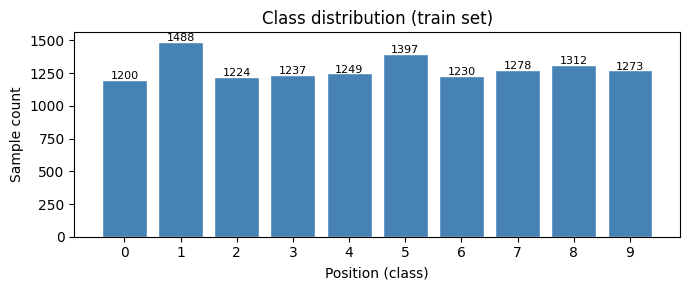

position
0    1200
1    1488
2    1224
3    1237
4    1249
5    1397
6    1230
7    1278
8    1312
9    1273
Name: count, dtype: int64


In [14]:
# Target distribution
fig, ax = plt.subplots(figsize=(7, 3))
counts = train['position'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Position (class)')
ax.set_ylabel('Sample count')
ax.set_title('Class distribution (train set)')
ax.set_xticks(range(10))
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(counts)

The class distribution is **approximately balanced**, with a similar number of samples for each class. Therefore, no specific techniques for handling class imbalance were required.


### **1.3 Feature Analysis**

#### 1.3.1 Non-CSI Features

In [15]:
# Non-CSI features
train[['seq_ctrl', 'aoa', 'rssi1', 'rssi2']].describe()

,seq_ctrl,aoa,rssi1,rssi2
count,12888.000,12888.000,12888.000,12888.000
mean,16008.410,15.017,-78.052,-77.952
std,19829.509,3087.311,6.805,8.349
min,0.000,-8703.000,-97.000,-94.000
25%,0.000,-1751.000,-83.000,-84.000
50%,5464.000,-30.000,-80.000,-80.000
75%,29424.000,1798.000,-74.000,-71.000
max,65520.000,8915.000,-58.000,-58.000


The non-CSI features (seq_ctrl, aoa, rssi1, rssi2) show different statistical properties. The **RSSI** values are within a reasonable range (around -80 dBm), providing meaningful signal strength information. The **aoa** feature presents a very large variance and extreme values, indicating that it may require normalization before being used. The **seq_ctrl** feature behaves as a sequence counter and is not expected to provide useful information for classification.

#### 1.3.2 CSI Features


CSI captures the effect of the wireless channel on the transmitted signal, including multipath propagation and fading, which makes it highly informative for localization tasks.

Each sample contains raw Channel State Information (CSI) measurements from two antennas. For each antenna, 64 OFDM subcarriers are recorded, and each subcarrier is represented by two values: the in-phase (I) and quadrature (Q) components. Therefore, each sample includes 256 CSI-related features (64 subcarriers × 2 components × 2 antennas). These values correspond to the complex representation of the wireless channel.

In [17]:
csi_cols = train.columns[4:-1]  # després de seq_ctrl, aoa, rssi1, rssi2
print("Number of CSI columns:", len(csi_cols))

Number of CSI columns: 256


In [18]:
print(csi_cols[:10])

Index(['I0_1', 'Q0_1', 'I1_1', 'Q1_1', 'I2_1', 'Q2_1', 'I3_1', 'Q3_1', 'I4_1',
       'Q4_1'],
      dtype='object')


Since CSI is represented in terms of I/Q components, it may be beneficial to transform these values into amplitude and phase representations, which are more interpretable from a physical perspective.
Additionally, not all subcarriers carry useful information, as some correspond to guard bands or DC components. These will be analyzed and potentially removed in later stages.

In particular, phase differences between antennas are expected to be highly informative for localization, as they encode spatial information about the signal propagation.

## **2. Preprocessing and Feature Engineering**

### **2.1 Cleaning decisions**

Based on the exploratory data analysis, the **seq_ctrl** feature is removed since it acts as a packet sequence counter and does not provide meaningful information for the classification task. The remaining features (aoa, rssi1, rssi2, and CSI components) are retained. The aoa feature will be normalized in a later stage due to its large variance.

In [26]:
print(X1.shape)

(12888, 260)


In [27]:
X = X1.drop(columns=["seq_ctrl"])
Xtest = test.drop(columns=["seq_ctrl"])

In [28]:
print(X.shape)
print(Xtest.shape)

(12888, 259)
(3223, 259)


The seq_ctrl feature was removed from both the training and test datasets, reducing the number of features from 260 to 259. This feature was discarded because it acts as a packet sequence counter and does not provide relevant information for the classification task.

### **2.2 CSI transformation**

In [29]:
csi_cols = X.columns[3:]  # després de aoa, rssi1, rssi2
print(len(csi_cols))

256


In [30]:
csi_train = X[csi_cols].values

**Separar antenes**

In [31]:
# 128 per antena
ant1_train = csi_train[:, :128]
ant2_train = csi_train[:, 128:]

**Separar I i Q**

In [32]:
# antenna 1
I1_tr = ant1_train[:, 0::2]
Q1_tr = ant1_train[:, 1::2]

# antenna 2
I2_tr = ant2_train[:, 0::2]
Q2_tr = ant2_train[:, 1::2]

**Amplitud i fase**

In [33]:
amp1_tr = np.sqrt(I1_tr**2 + Q1_tr**2)
amp2_tr = np.sqrt(I2_tr**2 + Q2_tr**2)

phase1_tr = np.arctan2(Q1_tr, I1_tr)
phase2_tr = np.arctan2(Q2_tr, I2_tr)

**Nova feature**

In [34]:
phase_diff_tr = phase2_tr - phase1_tr

In [35]:
print(amp1_tr.shape)      # (12888, 64)
print(phase_diff_tr.shape)

(12888, 64)
(12888, 64)


| Feature    | Significat           |
| ---------- | -------------------- |
| amplitud   | força del senyal     |
| fase       | retard               |
| phase_diff | direcció / posició |


***Fem el mateix pel test***

In [40]:
csi_test = Xtest[csi_cols].values

ant1_test = csi_test[:, :128]
ant2_test = csi_test[:, 128:]

I1_te = ant1_test[:, 0::2]
Q1_te = ant1_test[:, 1::2]

I2_te = ant2_test[:, 0::2]
Q2_te = ant2_test[:, 1::2]

amp1_te = np.sqrt(I1_te**2 + Q1_te**2)
amp2_te = np.sqrt(I2_te**2 + Q2_te**2)

phase1_te = np.arctan2(Q1_te, I1_te)
phase2_te = np.arctan2(Q2_te, I2_te)

phase_diff_te = phase2_te - phase1_te

In [41]:
print(amp1_te.shape)     
print(phase_diff_te.shape)

(3223, 64)
(3223, 64)


### **2.3 Feature engineering**

**Construim features noves**

In [42]:
X_csi = pd.DataFrame(index=X.index)
Xtest_csi = pd.DataFrame(index=Xtest.index)

for k in range(64):
    X_csi[f"amp1_{k}"] = amp1_tr[:, k]
    X_csi[f"amp2_{k}"] = amp2_tr[:, k]
    X_csi[f"phase_diff_{k}"] = phase_diff_tr[:, k]

    Xtest_csi[f"amp1_{k}"] = amp1_te[:, k]
    Xtest_csi[f"amp2_{k}"] = amp2_te[:, k]
    Xtest_csi[f"phase_diff_{k}"] = phase_diff_te[:, k]

In [43]:
X_base = X[["aoa", "rssi1", "rssi2"]].copy()
Xtest_base = Xtest[["aoa", "rssi1", "rssi2"]].copy()

X_base["rssi_diff"] = X_base["rssi1"] - X_base["rssi2"]
Xtest_base["rssi_diff"] = Xtest_base["rssi1"] - Xtest_base["rssi2"]

X_final = pd.concat([X_base, X_csi], axis=1)
Xtest_final = pd.concat([Xtest_base, Xtest_csi], axis=1)

print(X_final.shape)
print(Xtest_final.shape)

(12888, 196)
(3223, 196)


After transforming the raw CSI data, the final feature set contains 196 features for each sample. This includes **4 non-CSI features** (aoa, rssi1, rssi2, and rssi_diff) and **192 CSI-derived features**.

The CSI features are obtained by computing the amplitude for each antenna (64 subcarriers per antenna, resulting in 128 features) and the phase difference between antennas (64 features).

This transformation reduces the original 256 I/Q components into a more compact and physically meaningful representation, improving interpretability while preserving the most relevant information for the classification task.

### **2.4 Scaling**

The features in the dataset have very different scales (e.g., aoa has large magnitude values, while phase differences are in radians and RSSI values are in dBm). To ensure that all features contribute equally to the learning process, standardization is applied using the mean and standard deviation computed from the training set.

In [44]:
scaler = StandardScaler()

# IMPORTANT: fit només amb train
X_scaled = scaler.fit_transform(X_final)

# transformar test amb el mateix scaler
Xtest_scaled = scaler.transform(Xtest_final)

In [45]:
#check
print(X_scaled.shape, Xtest_scaled.shape)

(12888, 196) (3223, 196)


### **2.4 Feature selection**